# Measurement
A qubit exists in a superposition of $\ket{0}$ and $\ket{1}$. However, upon measurement, we get a single, definite value. As a result, the measurement will yield either $\ket{0}$ or $\ket{1}$, each with a specific probability, rather than a superposition of $\ket{0}$ *and* $\ket{1}$.

In this demonstration, we will explore qubit measurement using IBM Quantum Composer and Qiskit.

1. [Calculating Measurement](#1.-Calculating-Measurement)
2. [IBM Quantum Composer](#2.-IBM-Quantum-Composer)  
3. [Qiskit Implementation](#3.-Qiskit-Implementation)  
4. [Example](#4.-Example)

IBM Quantum Composer: https://quantum.ibm.com/composer/

## 1. Calculating Measurement
Consider the application of the Hadamard gate to the state $\ket{0}$. The resulting superposition is $\frac{1}{\sqrt{2}}\left(\ket{0} + \ket{1}\right) = \frac{1}{\sqrt{2}}\ket{0} + \frac{1}{\sqrt{2}}\ket{1}$.

To get the exact probabilities of $\ket{0}$ and $\ket{1}$, we calculate the norm-square of each amplitude.

Probability of $\ket{0}$: $(\frac{1}{\sqrt{2}})^2 = \frac{1}{2}$

Probability of $\ket{1}$: $(\frac{1}{\sqrt{2}})^2 = \frac{1}{2}$

We can verify this by confirming that the sum of both probabilities is equal to $1$.

## 2. IBM Quantum Composer

### 2.1 Start with the $\ket{0}$
Add a classical bit for every qubit you want to measure. In this case, we only add one.
#### (Note that initially the qubit already begins in the $\ket{0}$ state. We only apply this reset operation for visualization purposes)
<img src="measurement_images/start_state.png">
<img src="measurement_images/start_probability.png">

### 2.2 Use Hadamard Gate to generate $\frac{1}{\sqrt{2}}\left(\ket{0} + \ket{1}\right)$
<img src="measurement_images/hadamard.png">
<img src="measurement_images/hadamard_gate.png">

### 2.3 Apply Measurement 
<img src="measurement_images/measured_state.png">

### 2.4 Result
Now, we can set up and run the circuit on real quantum hardware. If you are not logged in, log in. Set up and run the circuit using the blue button in the top right. Choose the quantum computer you want to run on and keep the default number of shots. Run the circuit.

<img src="measurement_images/result.png">

## 3. Qiskit Implementation
### Imports

In [1]:
%pip install qiskit
%pip install qiskit-aer

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### 3.1 Constructing our Circuit

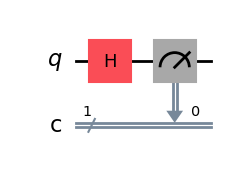

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1, 1)
qc.h(0)
measurement = qc.measure(0, 0)
qc.draw(output="mpl")

### 3.2 Measurement
To measure this circuit, Qiskit provides simulators to execute the circuits and obtain measurements. We can also call the backend of real quantum hardware such as <b>ibm_rensselaer</b> to execute our circuit. The number of shots specify how many copies of the circuit are created and run. This gives us a probability distribution over the possible states, $\ket{0}$ and $\ket{1}$.

In [3]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()
job = simulator.run(qc, shots=1000) # How many copies of the circuit are executed

# Get the result and count the occurrences of each outcome
result = job.result()
counts = result.get_counts(qc)

print("Measurement results:", counts)

Measurement results: {'1': 496, '0': 504}


The results match our calculated measurements.

## 4. Example
We demonstrate a more complex example. Consider:

$$
\ket{\psi} = \frac{2}{3}\ket{0} + \frac{1 + 2i}{3}\ket{1}
$$

If you measure the qubit, what is the probability of getting:

1. $\ket{0}$

2. $\ket{1}$

### 4.1 Calculating Measurement
Probability of $\ket{0}$: $(\frac{2}{3})^2 = \frac{4}{9}$

Probability of $\ket{1}$: $(\frac{1+2i}{3})^2 = (\frac{1+2i}{3})(\frac{1-2i}{3}) = \frac{1+4}{9} = \frac{5}{9}$

Verification: $\frac{4}{9} + \frac{5}{9} = 1$

### 4.2 IBM Quantum Composer
To construct $\ket{\psi}$ as a circuit, begin in $\ket{0}$. Then apply a $Ry$ gate with $\theta = \arccos(1.68213734)$ and a $Rz$ gate with $\phi = \arctan(1.1071)$. We will not dive into the calculation. Finally, measure the qubit.

<img src="measurement_images/example.png">

Set up and run the circuit with default number of shots. Verify the results.

<img src="measurement_images/example_results.png">

## Practice Questions

### 1. What state is a qubit in before any gates are applied?

A. |1⟩  
B. |0⟩  
C. A superposition state  
D. A classical bit  

**Answer:** B  


---

### 2. What does measuring a qubit produce?

A. A probability distribution  
B. A classical result of 0 or 1  
C. Another qubit  
D. A quantum gate  

**Answer:** B  


---

### 3. Why do the bar charts show frequencies instead of a single outcome?

A. The circuit is executed multiple times  
B. The qubit duplicates itself  
C. The gates repeat automatically  
D. The measurement is deterministic  

**Answer:** A  


---

### 4. What effect does the Hadamard (H) gate have before measurement?

A. It forces the result to always be 0  
B. It removes the qubit  
C. It creates a superposition that leads to roughly equal measurement probabilities  
D. It duplicates the circuit  

**Answer:** C  


---

### 5. What determines the probability of measuring 0 or 1?

A. The number of qubits in the computer  
B. The quantum gates applied before measurement  
C. The classical register size  
D. The execution seed  

**Answer:** B  


In [1]:
import ipywidgets as widgets
from IPython.display import display, HTML

def make_question(q_num, question, options, correct):
    
    question_html = widgets.HTML(
        value=f"""
        <div style="color: black; font-size: 16px; line-height: 1.6;">
            <h4 style="margin-bottom: 10px;">Q{q_num}: {question}</h4>
            {''.join([f"<div>{opt}</div>" for opt in options])}
        </div>
        """
    )

    radio = widgets.RadioButtons(
        options=["A", "B", "C", "D"],
        value=None,
        description="Select:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="120px")
    )

    button = widgets.Button(
        description="Check Answer",
        button_style="info"
    )

    output = widgets.Output()

    def check_answer(b):
        output.clear_output(wait=True)
        with output:
            if radio.value is None:
                print("Select an answer first.")
            elif radio.value == correct:
                print("Correct!")
            else:
                print("Incorrect. Try again.")

    button.on_click(check_answer)

    display(question_html, radio, button, output)

make_question(
    1,
    "What state is a qubit in before any gates are applied?",
    [
        "A. |1⟩",
        "B. |0⟩",
        "C. A superposition state",
        "D. A classical bit"
    ],
    "B"
)

make_question(
    2,
    "What does measuring a qubit produce?",
    [
        "A. A probability distribution",
        "B. A classical result of 0 or 1",
        "C. Another qubit",
        "D. A quantum gate"
    ],
    "B"
)

make_question(
    3,
    "Why do the bar charts show frequencies instead of a single outcome?",
    [
        "A. The circuit is executed multiple times",
        "B. The qubit duplicates itself",
        "C. The gates repeat automatically",
        "D. The measurement is deterministic"
    ],
    "A"
)

make_question(
    4,
    "What effect does the Hadamard (H) gate have before measurement?",
    [
        "A. It forces the result to always be 0",
        "B. It removes the qubit",
        "C. It creates a superposition that leads to roughly equal measurement probabilities",
        "D. It duplicates the circuit"
    ],
    "C"
)

make_question(
    5,
    "What determines the probability of measuring 0 or 1?",
    [
        "A. The number of qubits in the computer",
        "B. The quantum gates applied before measurement",
        "C. The classical register size",
        "D. The execution seed"
    ],
    "B"
)

HTML(value='\n        <div style="color: black; font-size: 16px; line-height: 1.6;">\n            <h4 style="m…

RadioButtons(description='Select:', layout=Layout(width='120px'), options=('A', 'B', 'C', 'D'), style=Descript…

Button(button_style='info', description='Check Answer', style=ButtonStyle())

Output()

HTML(value='\n        <div style="color: black; font-size: 16px; line-height: 1.6;">\n            <h4 style="m…

...

Output()

HTML(value='\n        <div style="color: black; font-size: 16px; line-height: 1.6;">\n            <h4 style="m…

RadioButtons(description='Select:', layout=Layout(width='120px'), options=('A', 'B', 'C', 'D'), style=Descript…

Button(button_style='info', description='Check Answer', style=ButtonStyle())

Output()